This notebook is for analyzing transportation data for January 2026. This creates a snapshot into the data, looking especially at origin-demand flows for the current time period. It is a baseline to calibrate the commute model to; e.g. inputs to the model that match the time for Jan 2026 should output this OD graph.

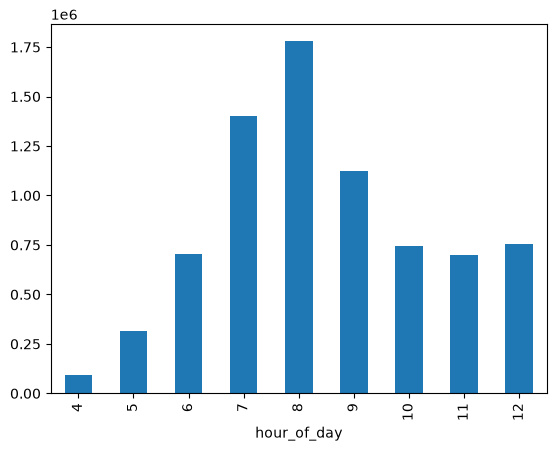

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import geopandas as gpd

# building baseline OD graph (current commuting pattern)
# Parquet made by scripts/convert_mta_od.py (columns already snake_case)
mta = pd.read_parquet("../data/interim/mta_od_2026-01.parquet")

# graphing hourly ridership to determine peak hours
commute_graph = mta.groupby("hour_of_day")["estimated_average_ridership"].sum().plot(kind="bar")

In [2]:
# setting peak hours to be from 7am to 9am based on the commute graph
weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
peak = mta[mta["day_of_week"].isin(weekdays)
          & (mta["hour_of_day"] >= 7) & (mta["hour_of_day"] <= 9)]  # assuming 7-9 AM is peak hour
flows = (peak.groupby(["origin_station_complex_id", "destination_station_complex_id"])
           ["estimated_average_ridership"].sum()
           .div(5 * 3)          # 5 weekdays x 3 hours -> avg riders per hour (adjust for months pulled)
           .reset_index(name="riders"))
           
print(flows)
G_current_od = nx.DiGraph()
for r in flows.itertuples(index=False):
    if r[0] != r[1] and r.riders > 0:
        G_current_od.add_edge(r[0], r[1], weight=r.riders)

# station coordinates as node attributes, for maps and for matching to GTFS later
coords = peak.drop_duplicates("origin_station_complex_id").set_index("origin_station_complex_id")
nx.set_node_attributes(G_current_od, coords["origin_latitude"].to_dict(), "lat")
nx.set_node_attributes(G_current_od, coords["origin_longitude"].to_dict(), "lon") 


        origin_station_complex_id  destination_station_complex_id     riders
0                               1                               2   6.955180
1                               1                               3  15.214173
2                               1                               4  11.264780
3                               1                               5  18.756273
4                               1                               6  18.300300
...                           ...                             ...        ...
149170                        636                             627   4.114193
149171                        636                             628  69.140693
149172                        636                             629   0.815027
149173                        636                             630   0.880907
149174                        636                             635  19.781233

[149175 rows x 3 columns]


In [3]:
# loading FHV data from TLC (yellow, green, and high volume for hire vehicles)
# data is all from Jan 2026
green_taxi = pd.read_parquet("../data/raw/tlc/green_tripdata_2026-01.parquet")
yellow_taxi = pd.read_parquet("../data/raw/tlc/yellow_tripdata_2026-01.parquet")
# high volume for hire vehicles include Uber/Lyft
fhv_hv = pd.read_parquet("../data/raw/tlc/fhvhv_tripdata_2026-01.parquet")


In [44]:
# loading CitiBike data for Jan 2026
citi_bike_1 = pd.read_csv("../data/raw/citibike/202601-citibike-tripdata/202601-citibike-tripdata_1.csv")
citi_bike_2 = pd.read_csv("../data/raw/citibike/202601-citibike-tripdata/202601-citibike-tripdata_2.csv")

/var/folders/yf/2m7vdqqs0v16g0qhwl70d1700000gn/T/ipykernel_82899/1144163485.py:2: DtypeWarning: Columns (7: end_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  citi_bike_1 = pd.read_csv("../data/raw/citibike/202601-citibike-tripdata/202601-citibike-tripdata_1.csv")


In [45]:
citi_bike_1["started_at"] = pd.to_datetime(citi_bike["started_at"])
print(citi_bike_1["started_at"].sort_values().head())
print(citi_bike_1["started_at"].sort_values().tail())

# note: there are some trips in here that start at the end of december since they end in jan. keeping for now.

808735   2025-12-30 23:30:09.507
797002   2025-12-31 08:17:50.624
810125   2025-12-31 08:35:48.405
805048   2025-12-31 08:55:13.818
797612   2025-12-31 09:16:13.818
Name: started_at, dtype: datetime64[us]
755691   2026-01-14 18:59:57.395
289273   2026-01-14 18:59:58.184
153574   2026-01-14 18:59:58.530
475831   2026-01-14 18:59:59.273
204614   2026-01-14 18:59:59.453
Name: started_at, dtype: datetime64[us]


In [46]:
citi_bike_2["started_at"] = pd.to_datetime(citi_bike_2["started_at"])
print(citi_bike_2["started_at"].sort_values().head())
print(citi_bike_2["started_at"].sort_values().tail())

4723    2025-12-31 23:32:23.856
5773    2025-12-31 23:32:39.108
5399    2025-12-31 23:33:31.169
5839    2025-12-31 23:35:33.073
38764   2025-12-31 23:39:54.323
Name: started_at, dtype: datetime64[us]
665244   2026-01-31 23:54:35.137
310108   2026-01-31 23:54:39.696
683535   2026-01-31 23:55:06.916
530696   2026-01-31 23:56:45.257
273062   2026-01-31 23:56:50.315
Name: started_at, dtype: datetime64[us]


In [50]:
# concantenating the two CitiBike dataframes
citi_bike = pd.concat([citi_bike_1, citi_bike_2], ignore_index=True)
print(citi_bike.head(2))

# testing if there are duplicates between the two files
assert(citi_bike.shape[0] == citi_bike.drop_duplicates(subset=['ride_id']).shape[0])

# found: no duplicates

            ride_id  rideable_type              started_at  \
0  85744AF35D7F2DF5  electric_bike 2026-01-02 05:36:24.539   
1  9D18958E5788880B  electric_bike 2026-01-02 15:15:11.915   

                  ended_at    start_station_name start_station_id  \
0  2026-01-02 05:42:21.153       W 42 St & 8 Ave          6602.05   
1  2026-01-02 15:18:40.462  Division St & Bowery          5311.08   

        end_station_name end_station_id  start_lat  start_lng    end_lat  \
0  E 58 St & Madison Ave        6839.04   40.75757 -73.990985  40.763026   
1  Clinton St & Grand St       5303.06_   40.71419 -73.996730  40.715738   

     end_lng member_casual  
0 -73.972095        member  
1 -73.986990        member  


   OBJECTID  Shape_Leng  Shape_Area                     zone  LocationID  \
0         1    0.116357    0.000782           Newark Airport           1   
1         2    0.433470    0.004866              Jamaica Bay           2   
2         3    0.084341    0.000314  Allerton/Pelham Gardens           3   
3         4    0.043567    0.000112            Alphabet City           4   
4         5    0.092146    0.000498            Arden Heights           5   

         borough                                           geometry  
0            EWR  POLYGON ((933100.918 192536.086, 933091.011 19...  
1         Queens  MULTIPOLYGON (((1033269.244 172126.008, 103343...  
2          Bronx  POLYGON ((1026308.77 256767.698, 1026495.593 2...  
3      Manhattan  POLYGON ((992073.467 203714.076, 992068.667 20...  
4  Staten Island  POLYGON ((935843.31 144283.336, 936046.565 144...  
EPSG:2263


<Axes: >

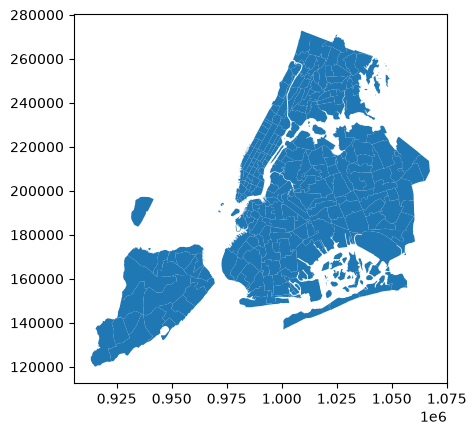

In [ ]:
# taxi zone shape file
# need to map subways and CitiBike stations to taxi zones for OD matching since zones are not on the same reference points as each other

taxi_zones = gpd.read_file("../data/raw/zones/taxi_zones/taxi_zones.shp")
print(taxi_zones.head())
print(taxi_zones.crs)         # NY State Plane, in feet
taxi_zones.plot()      # quick map to check it loaded

In [ ]:
# get unique subway stations, from both origins and destinations
orig = mta[["origin_station_complex_id", "origin_latitude", "origin_longitude"]]
dest = mta[["destination_station_complex_id", "destination_latitude", "destination_longitude"]]

# rename the columns to that they are the same for both dataframes, so we can concat them together
dest.columns = orig.columns = ["station_id", "lat", "lon"]
mta_stations = pd.concat([orig, dest]).drop_duplicates("station_id")

# build points in lat/lon (EPSG:4326) since that's the coordinate reference system (CRS) of the original data, then project to NY State Plane feet (EPSG:2263) so that it matches the taxi data 
mta_stations = gpd.GeoDataFrame(
    mta_stations,
    geometry=gpd.points_from_xy(mta_stations["lon"], mta_stations["lat"]),  # x = lon, y = lat
    crs=4326,
).to_crs(2263)

# taxi zones are already in 2263
taxi_zones = gpd.read_file("../data/raw/zones/taxi_zones/taxi_zones.shp")
assert mta_stations.crs == taxi_zones.crs

# now we are building station_zones which matches each subway station to the taxi zone it is located in

# sjoin = spatial join, which will match the stations to the taxi zones based on their geometry
# this is the same as a pandas merge, but the matching is based on location (geometry) 
# how = left: keep all rows from the left dataframe (mta_stations) and add columns from the right dataframe (taxi_zones) where there is a match
# predicate = within: match if the point (station) is within the polygon (taxi zone), should be used if left geometry is completely within right geometry

station_zones = gpd.sjoin(
    mta_stations, taxi_zones[["LocationID", "zone", "borough", "geometry"]],
    how="left", predicate="within",
)

# checking each station got matched to a taxi zone
print(len(station_zones), len(mta_stations))
print(station_zones["LocationID"].isna().sum()) 

print(station_zones.head())

# convert mta station coordinates to 2263 (originall in lat/long) to match taxi zones
mta_stations = mta_stations.to_crs(2263)

424 424
0
   station_id        lat        lon                        geometry  \
0          35  40.641362 -74.017881   POINT (979287.581 172942.355)   
1         146  40.851695 -73.937969  POINT (1001410.868 249579.017)   
2         252  40.589620 -73.974250   POINT (991401.803 154091.933)   
3          51  40.608670 -73.957734   POINT (995985.606 161034.116)   
4         209  40.603995 -73.755405  POINT (1052169.082 159422.886)   

   index_right  LocationID                      zone    borough  
0          227         228          Sunset Park West   Brooklyn  
1          242         243  Washington Heights North  Manhattan  
2          107         108                 Gravesend   Brooklyn  
3          148         149                   Madison   Brooklyn  
4           85          86              Far Rockaway     Queens  


In [ ]:
stations = (mta[["origin_station_complex_id", "origin_latitude", "origin_longitude"]]
              .drop_duplicates("origin_station_complex_id"))
stations = gpd.GeoDataFrame(
    stations,
    geometry=gpd.points_from_xy(stations.origin_longitude, stations.origin_latitude),
    crs=4326)

station_zone = gpd.sjoin(stations, taxi_zones[["LocationID", "zone", "borough", "geometry"]],
                         how="left", predicate="within")
station_zone["LocationID"].isna().sum()   # stations that didn't land in a zone; should be 0
